In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import json

sys.path.append(os.path.abspath('../'))
from src.word2vec import Word2Vec
from src.data_pipeline import load_corpus, generate_training_data

In [5]:
corpus = load_corpus("../data/processed/toy_corpus.txt")

In [6]:
with open('../data/processed/vocab.json',encoding='utf-8') as f:
    word2id=json.load(f)['word2id']

In [ ]:
training_data=generate_training_data(corpus,word2id)
training_data

In [9]:
EMBEDDING_DIM = 50
LEARNING_RATE = 0.05
EPOCHS = 10
VOCAB_SIZE=len(word2id)

model = Word2Vec(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, learning_rate=LEARNING_RATE)
loss_history = model.train(training_data, epochs=EPOCHS)

Bắt đầu huấn luyện Word2Vec trong 10 Epochs...
Epoch 001/10 | Trị giá sai số (Loss): 8.3002
Epoch 002/10 | Trị giá sai số (Loss): 6.4616
Epoch 003/10 | Trị giá sai số (Loss): 5.7302
Epoch 004/10 | Trị giá sai số (Loss): 5.2709
Epoch 005/10 | Trị giá sai số (Loss): 4.9448
Epoch 006/10 | Trị giá sai số (Loss): 4.7012
Epoch 007/10 | Trị giá sai số (Loss): 4.5168
Epoch 008/10 | Trị giá sai số (Loss): 4.3781
Epoch 009/10 | Trị giá sai số (Loss): 4.2747
Epoch 010/10 | Trị giá sai số (Loss): 4.1976


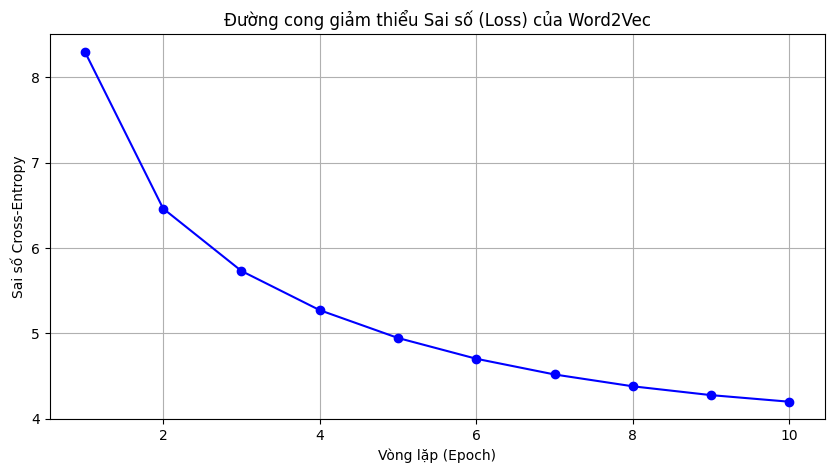

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', linestyle='-', color='b')
plt.title('Đường cong giảm thiểu Sai số (Loss) của Word2Vec')
plt.xlabel('Vòng lặp (Epoch)')
plt.ylabel('Sai số Cross-Entropy')
plt.grid(True)
plt.show()

In [18]:
id2word = {0: "phòng_trọ", 1: "máy_lạnh", 2: "giá_rẻ", 3: "sinh_viên", 4: "căn_hộ"}
    
training_data = [
    (0, 1), (1, 0), # phòng_trọ <-> máy_lạnh
    (0, 2), (2, 0), # phòng_trọ <-> giá_rẻ
    (0, 3), (3, 0), # phòng_trọ <-> sinh_viên
    
    (4, 1), (1, 4), # căn_hộ <-> máy_lạnh
    (4, 2), (2, 4), # căn_hộ <-> giá_rẻ 
]

model = Word2Vec(vocab_size=5, embedding_dim=3, learning_rate=0.05)
model.train(training_data, epochs=500)


test_word_id = 0 # Từ "phòng_trọ"
test_word = id2word[test_word_id]

print(f"Dự đoán từ đi kèm với '{test_word}'")
predictions = model.predict_context(test_word_id, top_n=3)
for idx, prob in predictions:
    print(f" -> AI đoán: {id2word[idx]} (Xác suất: {prob*100:.1f}%)")
    


Bat dau huan luyen Word2Vec trong 500 Epochs...
Epoch 001/500 | Tri gia sai so (Loss): 1.7793
Epoch 002/500 | Tri gia sai so (Loss): 1.6965
Epoch 003/500 | Tri gia sai so (Loss): 1.6281
Epoch 004/500 | Tri gia sai so (Loss): 1.5687
Epoch 005/500 | Tri gia sai so (Loss): 1.5152
Epoch 006/500 | Tri gia sai so (Loss): 1.4657
Epoch 007/500 | Tri gia sai so (Loss): 1.4192
Epoch 008/500 | Tri gia sai so (Loss): 1.3752
Epoch 009/500 | Tri gia sai so (Loss): 1.3335
Epoch 010/500 | Tri gia sai so (Loss): 1.2941
Epoch 011/500 | Tri gia sai so (Loss): 1.2569
Epoch 012/500 | Tri gia sai so (Loss): 1.2220
Epoch 013/500 | Tri gia sai so (Loss): 1.1895
Epoch 014/500 | Tri gia sai so (Loss): 1.1594
Epoch 015/500 | Tri gia sai so (Loss): 1.1315
Epoch 016/500 | Tri gia sai so (Loss): 1.1058
Epoch 017/500 | Tri gia sai so (Loss): 1.0822
Epoch 018/500 | Tri gia sai so (Loss): 1.0606
Epoch 019/500 | Tri gia sai so (Loss): 1.0410
Epoch 020/500 | Tri gia sai so (Loss): 1.0231
Epoch 021/500 | Tri gia sai so (

In [19]:
print(f"Tìm các từ có tính chất giống '{test_word}' nhất")
print("(Kỳ vọng: AI phải biết 'phòng_trọ' và 'căn_hộ' là giống nhau vì cùng dùng 'máy_lạnh')")

similar_words = model.get_similar_words(test_word_id, top_n=3)
for idx, sim_score in similar_words:
    print(f" -> Từ liên quan: {id2word[idx]} (Độ tương đồng: {sim_score*100:.1f}%)")

Tìm các từ có tính chất giống 'phòng_trọ' nhất
(Kỳ vọng: AI phải biết 'phòng_trọ' và 'căn_hộ' là giống nhau vì cùng dùng 'máy_lạnh')
 -> Từ liên quan: căn_hộ (Độ tương đồng: 33.2%)
 -> Từ liên quan: máy_lạnh (Độ tương đồng: -79.9%)
 -> Từ liên quan: giá_rẻ (Độ tương đồng: -84.8%)
